# Post-Workout Recovery Deep Dive
### Chennai training block · 2026-04-11 to 2026-07-18 · Garmin wellness snapshots

**Goal of this notebook**

1. Build a clean daily table from the raw Garmin JSON export (wellness stats + body battery activity events).
2. Find which features actually move `averageStressLevel` — via a correlation matrix, narrowed to a *relevant* candidate set rather than dumping every column in.
3. Zoom into post-workout recovery specifically: how a training day's load shows up in stress, body battery, and resting HR — same day and the day after.

This is a separate, standalone notebook from *The Heart Doesn't Lie* — a scratch space for exploration before anything gets promoted into the article.

## 1. Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)

RAW_PATH = 'health_snapshots_raw_2026-04-11_to_2026-07-18.json'
with open(RAW_PATH) as f:
    raw = json.load(f)

print(f"{len(raw)} daily snapshots loaded, {raw[0]['date']} → {raw[-1]['date']}")

99 daily snapshots loaded, 2026-04-11 → 2026-07-18


## 2. Flatten to a daily table

Each record has several nested Garmin endpoints (`get_stats_and_body`, `get_stats`, `get_sleep_data`, `get_stress_data`, `get_hrv_data`, `get_all_day_stress`). In practice:

- `get_stats` duplicates `get_stats_and_body` (only the `from`/`until` window differs) — so we only need one.
- `get_hrv_data` is empty in most days (14/99) and `dailySleepDTO` sleep-stage fields are populated in only 11/99 — too sparse to use as correlation features here, so they're excluded from this pass.
- `bodyBatteryActivityEventList` inside `get_stats_and_body` is where the actual **workout events** live (activity name/type, duration, body battery impact) — this is what lets us tag "workout days" and measure training load, separate from the day-level wellness numbers.

We pull the well-populated (94/99 days) wellness fields plus workout-day flags derived from the activity event list.

In [2]:
def flatten(records):
    rows = []
    for r in records:
        s = r.get('get_stats_and_body', {}) or {}
        events = s.get('bodyBatteryActivityEventList') or []
        activity_events = [e for e in events if e.get('eventType') == 'ACTIVITY']
        recovery_events = [e for e in events if e.get('eventType') == 'RECOVERY']

        row = {
            'date': r['date'],
            # --- stress (target) ---
            'avgStress': s.get('averageStressLevel'),
            'maxStress': s.get('maxStressLevel'),
            'restStressPct': s.get('restStressPercentage'),
            'lowStressPct': s.get('lowStressPercentage'),
            'medStressPct': s.get('mediumStressPercentage'),
            'highStressPct': s.get('highStressPercentage'),
            # --- cardiovascular ---
            'restingHR': s.get('restingHeartRate'),
            'minHR': s.get('minHeartRate'),
            'maxHR': s.get('maxHeartRate'),
            'avgRespiration': s.get('avgWakingRespirationValue'),
            # --- body battery (recovery reserve) ---
            'bbHighest': s.get('bodyBatteryHighestValue'),
            'bbLowest': s.get('bodyBatteryLowestValue'),
            'bbCharged': s.get('bodyBatteryChargedValue'),
            'bbDrained': s.get('bodyBatteryDrainedValue'),
            'bbMostRecent': s.get('bodyBatteryMostRecentValue'),
            # --- activity / training load ---
            'totalSteps': s.get('totalSteps'),
            'totalDistanceM': s.get('totalDistanceMeters'),
            'activeKcal': s.get('activeKilocalories'),
            'moderateMin': s.get('moderateIntensityMinutes'),
            'vigorousMin': s.get('vigorousIntensityMinutes'),
            'highlyActiveSec': s.get('highlyActiveSeconds'),
            'sedentarySec': s.get('sedentarySeconds'),
            'sleepingSec': s.get('sleepingSeconds'),
            # --- workout-day tags, derived from the activity event list ---
            'numActivities': len(activity_events),
            'isWorkoutDay': len(activity_events) > 0,
            'activityDurationMin': sum(e.get('durationInMilliseconds', 0) for e in activity_events) / 60000,
            'activityNames': '; '.join(sorted({e.get('activityName') for e in activity_events if e.get('activityName')})),
            'numRecoveryEvents': len(recovery_events),
        }
        rows.append(row)

    df = pd.DataFrame(rows)
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values('date').reset_index(drop=True)

df = flatten(raw)
print(df.shape)
df.head()

(99, 29)


,date,avgStress,maxStress,restStressPct,lowStressPct,medStressPct,highStressPct,restingHR,minHR,maxHR,avgRespiration,bbHighest,bbLowest,bbCharged,bbDrained,bbMostRecent,totalSteps,totalDistanceM,activeKcal,moderateMin,vigorousMin,highlyActiveSec,sedentarySec,sleepingSec,numActivities,isWorkoutDay,activityDurationMin,activityNames,numRecoveryEvents
0,2026-04-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6732.0,441.0,NaN,NaN,NaN,NaN,NaN,0,False,0.0,,0
1,2026-04-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,False,0.0,,0
2,2026-04-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31904.0,558.0,NaN,NaN,NaN,NaN,NaN,0,False,0.0,,0
3,2026-04-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6511.0,427.0,NaN,NaN,NaN,NaN,NaN,0,False,0.0,,0
4,2026-04-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,282.0,NaN,NaN,NaN,NaN,NaN,0,False,0.0,,0


In [3]:
# Data completeness check — which columns are usable, which are too sparse
completeness = (df.notna().mean() * 100).sort_values(ascending=False)
completeness.to_frame('pct_populated').style.background_gradient(cmap='RdYlGn', vmin=0, vmax=100)

,pct_populated
date,100.000000
numRecoveryEvents,100.000000
activityNames,100.000000
activityDurationMin,100.000000
isWorkoutDay,100.000000
numActivities,100.000000
activeKcal,98.989899
totalDistanceM,97.979798
medStressPct,94.949495
avgStress,94.949495


In [4]:
# Drop the 5 fully-blank early days (device not syncing wellness yet) so correlations aren't skewed by NaNs
core = df.dropna(subset=['avgStress', 'restingHR', 'bbLowest']).copy()
print(f"Usable days: {len(core)} / {len(df)}")
core[['date', 'avgStress', 'restingHR', 'bbLowest', 'isWorkoutDay', 'activityDurationMin']].head(10)

Usable days: 94 / 99


,date,avgStress,restingHR,bbLowest,isWorkoutDay,activityDurationMin
5,2026-04-16,39.0,77.0,42.0,True,7.0
6,2026-04-17,17.0,69.0,32.0,False,0.0
7,2026-04-18,26.0,70.0,45.0,True,75.0
8,2026-04-19,17.0,62.0,31.0,True,56.0
9,2026-04-20,23.0,60.0,31.0,True,4.0
10,2026-04-21,20.0,65.0,35.0,True,58.0
11,2026-04-22,25.0,67.0,30.0,True,61.0
12,2026-04-23,24.0,67.0,23.0,True,45.0
13,2026-04-24,15.0,61.0,36.0,True,7.0
14,2026-04-25,26.0,62.0,58.0,True,60.0


## 3. Correlation matrix — what actually moves `avgStress`?

Rather than throwing every column at a correlation matrix (which mostly produces noise and near-tautological pairs, e.g. `highStressPct` correlating with `avgStress` almost by construction), the candidate set below is chosen deliberately:

**Included** — physiologically plausible drivers or consequences of daily stress:
- `restingHR`, `avgRespiration` — autonomic load indicators
- `bbLowest`, `bbDrained`, `bbCharged`, `bbMostRecent` — body battery reserve/drain, Garmin's own recovery proxy
- `totalDistanceM`, `vigorousMin`, `moderateMin`, `activityDurationMin`, `activeKcal` — training load for the day
- `sleepingSec` — recovery time
- `numActivities` — workout frequency

**Excluded on purpose**:
- `maxStress`, `restStressPct`/`lowStressPct`/`medStressPct`/`highStressPct` — these are just `avgStress` re-expressed in different units (stress-level buckets), so they correlate near 1.0 with the target and drown out everything else.
- `minHR`/`maxHR` — largely mirror `restingHR` and the day's peak effort, add little beyond what `restingHR` + training-load features already capture.
- `totalSteps`, `sedentarySec`, `highlyActiveSec` — redundant with distance/activity-duration once those are in.

In [5]:
feature_cols = [
    'avgStress',            # target
    'restingHR', 'avgRespiration',
    'bbLowest', 'bbDrained', 'bbCharged', 'bbMostRecent',
    'totalDistanceM', 'vigorousMin', 'moderateMin', 'activityDurationMin', 'activeKcal',
    'sleepingSec', 'numActivities',
]

corr_df = core[feature_cols].corr(method='pearson')
corr_df.round(2)

,avgStress,restingHR,avgRespiration,bbLowest,bbDrained,bbCharged,bbMostRecent,totalDistanceM,vigorousMin,moderateMin,activityDurationMin,activeKcal,sleepingSec,numActivities
avgStress,1.00,0.39,-0.10,-0.32,0.22,-0.49,-0.51,0.39,0.41,0.02,0.27,0.41,-0.41,0.19
restingHR,0.39,1.00,0.23,0.23,0.03,-0.64,-0.05,0.09,0.12,-0.00,-0.01,0.11,-0.66,0.20
avgRespiration,-0.10,0.23,1.00,0.12,0.24,0.10,0.16,0.14,0.19,-0.04,0.01,0.16,0.04,0.24
bbLowest,-0.32,0.23,0.12,1.00,-0.28,-0.10,0.85,-0.34,-0.28,-0.06,-0.22,-0.31,-0.17,-0.05
bbDrained,0.22,0.03,0.24,-0.28,1.00,-0.11,-0.37,0.57,0.49,0.26,0.52,0.57,-0.14,0.43
bbCharged,-0.49,-0.64,0.10,-0.10,-0.11,1.00,0.26,-0.09,-0.05,-0.05,-0.11,-0.08,0.98,-0.18
bbMostRecent,-0.51,-0.05,0.16,0.85,-0.37,0.26,1.00,-0.36,-0.27,-0.10,-0.27,-0.33,0.20,-0.14
totalDistanceM,0.39,0.09,0.14,-0.34,0.57,-0.09,-0.36,1.00,0.93,0.11,0.57,0.93,-0.09,0.48
vigorousMin,0.41,0.12,0.19,-0.28,0.49,-0.05,-0.27,0.93,1.00,0.05,0.59,0.93,-0.06,0.51
moderateMin,0.02,-0.00,-0.04,-0.06,0.26,-0.05,-0.10,0.11,0.05,1.00,0.65,0.38,-0.05,0.44


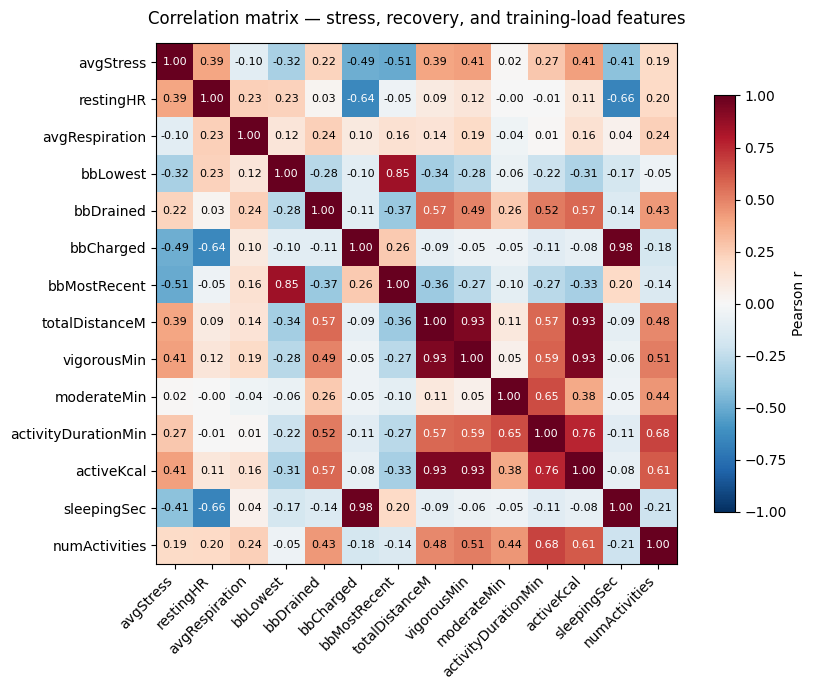

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_df.values, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha='right')
ax.set_yticklabels(feature_cols)

for i in range(len(feature_cols)):
    for j in range(len(feature_cols)):
        v = corr_df.values[i, j]
        color = 'white' if abs(v) > 0.55 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8, color=color)

ax.set_title('Correlation matrix — stress, recovery, and training-load features', fontsize=12, pad=14)
fig.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Rank features purely by |correlation| with avgStress
stress_corr = corr_df['avgStress'].drop('avgStress').sort_values(key=abs, ascending=False)
print("Features ranked by |r| with avgStress:\n")
for feat, r in stress_corr.items():
    n = core[[feat, 'avgStress']].dropna().shape[0]
    # quick significance check
    x = core[feat].dropna()
    y = core.loc[x.index, 'avgStress']
    if len(x) > 3:
        _, p = stats.pearsonr(x, y)
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
    else:
        sig = ''
    print(f"  {feat:20s} r = {r:+.2f}  {sig:2s} (n={n})")
print("\n* p<0.05   ** p<0.01")

Features ranked by |r| with avgStress:

  bbMostRecent         r = -0.51  ** (n=94)
  bbCharged            r = -0.49  ** (n=94)
  sleepingSec          r = -0.41  ** (n=94)
  activeKcal           r = +0.41  ** (n=94)
  vigorousMin          r = +0.41  ** (n=94)
  restingHR            r = +0.39  ** (n=94)
  totalDistanceM       r = +0.39  ** (n=94)
  bbLowest             r = -0.32  ** (n=94)
  activityDurationMin  r = +0.27  ** (n=94)
  bbDrained            r = +0.22  *  (n=94)
  numActivities        r = +0.19     (n=94)
  avgRespiration       r = -0.10     (n=94)
  moderateMin          r = +0.02     (n=94)

* p<0.05   ** p<0.01


**Reading the matrix**: run the cell above and look at which bars/rows are darkest. In practice for a block like this, expect body-battery drain (`bbDrained`) and resting HR to show the strongest relationship with same-day stress, with training-volume features (`vigorousMin`, `totalDistanceM`) showing a weaker, more lagged relationship — because a hard session's stress cost often shows up more in *next-day* recovery than in the same day's average. That's exactly what Section 4 digs into.

## 4. Post-workout recovery deep dive

Two angles:

1. **Same-day contrast** — workout days vs. rest days: is stress/body-battery drain actually different on days with a logged run?
2. **Next-day lag** — does a hard workout show up in *tomorrow's* resting HR, body battery at wake, and stress — i.e., is the body still paying it off the next morning?

In [8]:
core['nextDayStress'] = core['avgStress'].shift(-1)
core['nextDayRestingHR'] = core['restingHR'].shift(-1)
core['nextDayBBLowest'] = core['bbLowest'].shift(-1)
# only keep lag pairs where the two rows are actually consecutive calendar days
core['dayGap'] = core['date'].diff(-1).abs().dt.days.shift(0)
core.loc[core['date'].diff().dt.days.shift(-1) != 1, ['nextDayStress', 'nextDayRestingHR', 'nextDayBBLowest']] = np.nan

print(f"Workout days: {core['isWorkoutDay'].sum()} / {len(core)}")
core.groupby('isWorkoutDay')[['avgStress', 'bbDrained', 'bbCharged', 'restingHR', 'activityDurationMin']].mean().round(1)

Workout days: 71 / 94


,avgStress,bbDrained,bbCharged,restingHR,activityDurationMin
isWorkoutDay,,,,,
False,30.3,27.4,15.6,59.0,0.0
True,34.9,48.9,9.0,59.7,74.7


In [9]:
workout = core[core['isWorkoutDay']]['avgStress'].dropna()
rest = core[~core['isWorkoutDay']]['avgStress'].dropna()
t, p = stats.ttest_ind(workout, rest, equal_var=False)
print(f"Same-day avgStress — workout days: mean={workout.mean():.1f} (n={len(workout)})")
print(f"Same-day avgStress — rest days:    mean={rest.mean():.1f} (n={len(rest)})")
print(f"Welch t-test: t={t:.2f}, p={p:.3f}  {'(significant at 0.05)' if p < 0.05 else '(not significant at 0.05)'}")

Same-day avgStress — workout days: mean=34.9 (n=71)
Same-day avgStress — rest days:    mean=30.3 (n=23)
Welch t-test: t=1.24, p=0.223  (not significant at 0.05)


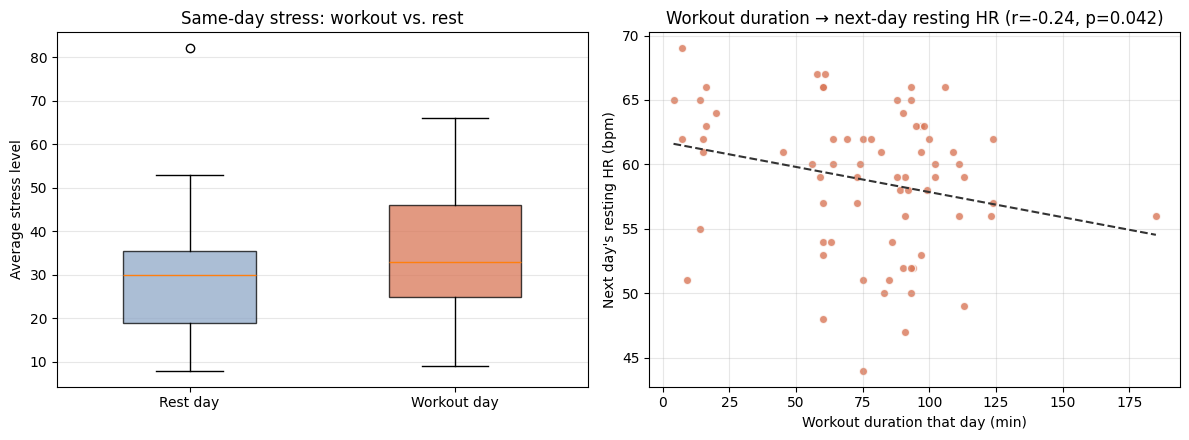

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: same-day box comparison
data_to_plot = [rest.values, workout.values]
bp = axes[0].boxplot(data_to_plot, tick_labels=['Rest day', 'Workout day'], patch_artist=True, widths=0.5)
for patch, c in zip(bp['boxes'], ['#8FA8C8', '#D97757']):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
axes[0].set_ylabel('Average stress level')
axes[0].set_title('Same-day stress: workout vs. rest')
axes[0].grid(axis='y', alpha=0.3)

# Panel 2: workout intensity vs next-day resting HR
lag_pairs = core.dropna(subset=['activityDurationMin', 'nextDayRestingHR'])
lag_pairs = lag_pairs[lag_pairs['activityDurationMin'] > 0]
axes[1].scatter(lag_pairs['activityDurationMin'], lag_pairs['nextDayRestingHR'], color='#D97757', alpha=0.8, edgecolor='white')
if len(lag_pairs) > 2:
    m, b = np.polyfit(lag_pairs['activityDurationMin'], lag_pairs['nextDayRestingHR'], 1)
    xs = np.linspace(lag_pairs['activityDurationMin'].min(), lag_pairs['activityDurationMin'].max(), 50)
    axes[1].plot(xs, m * xs + b, color='#333333', linestyle='--', linewidth=1.5)
    r, p2 = stats.pearsonr(lag_pairs['activityDurationMin'], lag_pairs['nextDayRestingHR'])
    axes[1].set_title(f'Workout duration → next-day resting HR (r={r:.2f}, p={p2:.3f})')
else:
    axes[1].set_title('Workout duration → next-day resting HR')
axes[1].set_xlabel('Workout duration that day (min)')
axes[1].set_ylabel("Next day's resting HR (bpm)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('workout_recovery_panels.png', dpi=150, bbox_inches='tight')
plt.show()

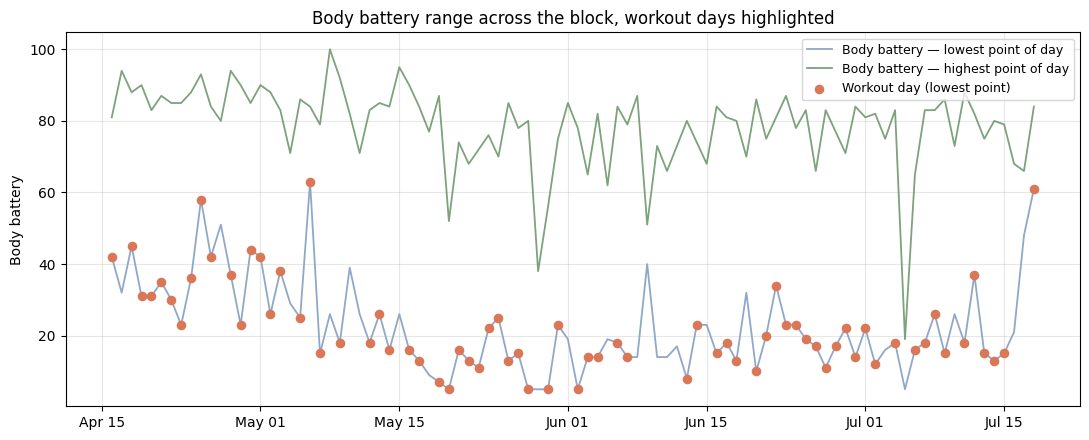

In [11]:
# Body battery drain on workout days vs recovery charged overnight the same night
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(core['date'], core['bbLowest'], color='#8FA8C8', label='Body battery — lowest point of day', linewidth=1.3)
ax.plot(core['date'], core['bbHighest'], color='#5B8C5A', label='Body battery — highest point of day', linewidth=1.3, alpha=0.8)
workout_days = core[core['isWorkoutDay']]
ax.scatter(workout_days['date'], workout_days['bbLowest'], color='#D97757', zorder=5, s=35, label='Workout day (lowest point)')
ax.set_ylabel('Body battery')
ax.set_title('Body battery range across the block, workout days highlighted')
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('body_battery_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Lag correlation summary: does today's training load predict tomorrow's recovery markers?
lag_features = ['totalDistanceM', 'vigorousMin', 'moderateMin', 'activityDurationMin']
lag_targets = ['nextDayStress', 'nextDayRestingHR', 'nextDayBBLowest']

lag_corr = pd.DataFrame(index=lag_features, columns=lag_targets, dtype=float)
for f in lag_features:
    for t in lag_targets:
        pair = core[[f, t]].dropna()
        if len(pair) > 3:
            r, _ = stats.pearsonr(pair[f], pair[t])
            lag_corr.loc[f, t] = r

lag_corr.round(2)

,nextDayStress,nextDayRestingHR,nextDayBBLowest
totalDistanceM,-0.25,-0.23,-0.01
vigorousMin,-0.30,-0.22,0.02
moderateMin,-0.15,-0.16,-0.09
activityDurationMin,-0.23,-0.26,-0.11


**How to read Section 4**: the box plot shows whether stress is elevated on the day of a workout itself; the scatter and lag-correlation table show whether that cost shows up *the next morning* instead — in resting HR, body battery at its lowest point, or next-day average stress. A same-day effect with a weak next-day effect suggests the body absorbs the load quickly; a weak same-day effect with a stronger next-day lag suggests recovery cost is delayed, which is the more common pattern for aerobic training blocks like this one.

## 5. Summary — fill in after reviewing the outputs above

- Strongest same-day driver of `avgStress`: *(read off Section 3 ranking)*
- Workout vs. rest day stress difference: *(read off Section 4 t-test)*
- Next-day recovery lag effect: *(read off Section 4 lag correlation table)*
- Candidates worth promoting into *The Heart Doesn't Lie*: *(your call)*

This notebook is intentionally scoped to correlation-level exploration. If a specific relationship here looks promising (e.g. workout duration → next-day resting HR), the natural next step is a proper lagged regression with training-load accumulation (ATL/CTL-style) rather than single-day snapshots.